In [5]:
import os
import warnings
import copy
import numpy as np
import pandas as pd
import sqlite3
import healpy as hp
import matplotlib.pyplot as plt
import colorcet as cc
import skyproj
from IPython.display import display, HTML
from tabulate import tabulate

from astropy.time import Time, TimeDelta
from astropy.coordinates import SkyCoord
import astropy.units as u

from rubin_scheduler.scheduler import sim_runner
from rubin_scheduler.scheduler.model_observatory import ModelObservatory
from rubin_scheduler.scheduler.schedulers import SimpleBandSched, DateSwapBandScheduler, CoreScheduler
from rubin_scheduler.scheduler.features import Conditions
from rubin_scheduler.scheduler.utils import SchemaConverter, run_info_table
from rubin_scheduler.site_models import Almanac
from rubin_scheduler.utils import ddf_locations, angular_separation, approx_ra_dec2_alt_az, Site
from rubin_scheduler.scheduler.utils import ObservationArray, generate_all_sky

import rubin_sim.maf as maf
from rubin_sim.data import get_baseline
import schedview.compute as schedview_compute

from rubin_nights import connections
import rubin_nights.dayobs_utils as rn_dayobs
import rubin_nights.plot_utils as rn_plots
import rubin_nights.augment_visits as augment_visits
import rubin_nights.observatory_status as observatory_status
import rubin_nights.rubin_scheduler_addons as rn_sch
import rubin_nights.rubin_sim_addons as rn_sim
from rubin_nights.targets_and_visits import targets_and_visits

import importlib

from sv_survey import sv_support as svs
import lsst.ts.fbs.utils.maintel.sv_config as svc

from sv_survey import fbs_config_sv_survey 

band_colors = rn_plots.PlotStyles.band_colors

In [2]:
out_dir = "lsstcam_20251011"
try:
    os.mkdir(out_dir)
except FileExistsError:
    pass

In [59]:
endpoints = connections.get_clients("/Users/lynnej/.lsst/usdf_rsp")

refresh_visits = False

if refresh_visits:
    query = ( 
        "select *, q.* from cdb_lsstcam.visit1 left join cdb_lsstcam.visit1_quicklook as q on visit1.visit_id = q.visit_id "
        "where visit1.day_obs > 20250414 and img_type != 'bias' and img_type != 'flat'" 
        #"where science_program = 'BLOCK-365' and observation_reason != 'block-t548' and observation_reason != 'field_survey_science'" 
          )
    visits = endpoints['consdb'].query(query)
    visits = augment_visits.augment_visits(visits, "lsstcam")
    
    visits.to_hdf('vall.h5', key='visits')
else:
    visits = pd.read_hdf('vall.h5')

In [60]:
# Flag filter changes 
filter_change = np.where((visits.band[:-1].values != visits.band[1:].values) 
                         & (visits.day_obs[:-1].values == visits.day_obs[1:].values))[0]
filter_change = filter_change + 1
fmask = np.zeros(len(visits))
fmask[filter_change] = 1
visits['filter_change'] = fmask

# calculate slew times 
wait_before_slew = 1.45
settle = 2.0
visits, slewing = rn_sch.add_model_slew_times(visits, endpoints['efd'], model_settle=wait_before_slew + settle, dome_crawl=False, slew_while_changing_filter=False)

max_scatter = 6
valid_overhead = np.min([np.where(np.isnan(visits.slew_model.values), 0, visits.slew_model.values) + max_scatter, visits.visit_gap.values], axis=0)
visits['overhead'] = valid_overhead

visits['fault'] = visits.visit_gap - visits.overhead

# But need to remove faults for the first visit of the night or where there was a different program we didn't fetch
# (could skip *some* of this by fetching all visits, but might still have some missing due to flats?)
skipped_visits = np.where(visits.visit_id[:-1].values + 1 != visits.visit_id[1:].values)[0] + 1
cidx = np.where(visits.columns == 'fault')[0]
visits.iloc[skipped_visits, cidx] = np.nan
cidx = np.where(visits.columns == 'model_gap')[0]
visits.iloc[skipped_visits, cidx] = np.nan

bad_visit_ids = augment_visits.fetch_excluded_visits("lsstcam")
gvisits = augment_visits.exclude_visits(visits, bad_visit_ids)
gvisits = gvisits.copy()

In [61]:
gvisits.to_hdf('gv_all_n.h5', key='visits')

/var/folders/tr/bjzqy0h17kx31fhndw6050d80000gn/T/ipykernel_15765/3505766912.py:1: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block2_values] [items->Index(['exposure_name', 'controller', 'physical_filter', 'band', 'exp_midpt',
       'obs_start', 'obs_end', 'group_id', 'img_type', 'emulated',
       'science_program', 'observation_reason', 'target_name', 'simulated',
       'vignette', 'vignette_min', 'scheduler_note', 's_region', 'can_see_sky',
       'pixel_scale_min', 'pixel_scale_max', 'psf_ap_flux_delta_min',
       'psf_ap_flux_delta_max', 'psf_ap_flux_delta_median',
       'psf_ap_corr_sigma_scaled_delta_min',
       'psf_ap_corr_sigma_scaled_delta_max',
       'psf_ap_corr_sigma_scaled_delta_median', 'seeing_zenith_500nm_min',
       'seeing_zenith_500nm_max', 'seeing_zenith_500nm_median',
       'low_snr_source_count_min', 'low_snr_source_count_max',
       'low_snr_sour

In [62]:
ee = endpoints['exposure_log'].query_log(Time(visits.obs_start.min()), Time(visits.obs_end.max()), user_params={"instruments": "LSSTCam"})
def make_visit_id(x):
    return int(f"{x.day_obs}{x.seq_num:05d}")
ee['visit_id'] = ee.apply(make_visit_id, axis=1)
ee = ee.merge(visits, how='left', on='visit_id')
ee = ee.query("science_program == 'BLOCK-365' and observation_reason != 'block-t548' and exposure_flag == 'junk'").copy()
print(len(ee), len(ee.visit_id.unique()))
print(len(bad_visit_ids))
print(len([b for b in bad_visit_ids if b not in ee.visit_id.values]), len([e for e in ee.visit_id.values if e not in bad_visit_ids]))

91 91
374
288 5


In [10]:
q = ee.query("visit_id not in @bad_visit_ids")
cols = ['visit_id', 'message_text', 'exposure_flag', 'user_id', 'tags', 'img_type', 'observation_reason', 'science_program', 'fwhm_eff', 'clouds']
display(HTML(q.sort_values(by='visit_id')[cols].to_html()))

,visit_id,message_text,exposure_flag,user_id,tags,img_type,observation_reason,science_program,fwhm_eff,clouds
204,2025071800160,Update on the flag\r\n,junk,leisert@summit-lsp.lsst.codes,[focus_issue],science,template_blob_u_33.0,BLOCK-365,2.445681,0.131918
51,2025071800161,Update on the flag\r\n,junk,leisert@summit-lsp.lsst.codes,[focus_issue],science,template_blob_u_33.0,BLOCK-365,2.023291,0.113333
223,2025071800162,Update on the flag\r\n,junk,leisert@summit-lsp.lsst.codes,[focus_issue],science,template_blob_u_33.0,BLOCK-365,1.765623,0.106745
173,2025071800163,Update on the flag\r\n,junk,leisert@summit-lsp.lsst.codes,[focus_issue],science,template_blob_u_33.0,BLOCK-365,1.567082,0.101290
107,2025071800164,Update on the flag\r\n,junk,leisert@summit-lsp.lsst.codes,[focus_issue],science,template_blob_u_33.0,BLOCK-365,1.448490,0.092521


In [17]:
svisits = gvisits.query("science_program == 'BLOCK-365' and observation_reason != 'block-t548'")
len(gvisits), len(svisits)

(50931, 21628)

In [13]:
#gvisits.query("science_program == 'BLOCK-365' and observation_reason != 'block-t548' and observation_reason != 'field_survey_science' and observation_reason != 'too'").scheduler_note.unique()

In [18]:
g_opsim = rn_sim.consdb_to_opsim(svisits)
filename = os.path.join(out_dir, 'lsstcam_20251011.db')
con = sqlite3.connect(filename)
g_opsim.to_sql("observations", con, index=False, if_exists="replace")
con.close()

In [19]:
ops_visits = rn_sim.consdb_to_opsim(svisits)
print(len(visits), len(bad_visit_ids), len(gvisits), len(ops_visits))

51299 368 50931 21628


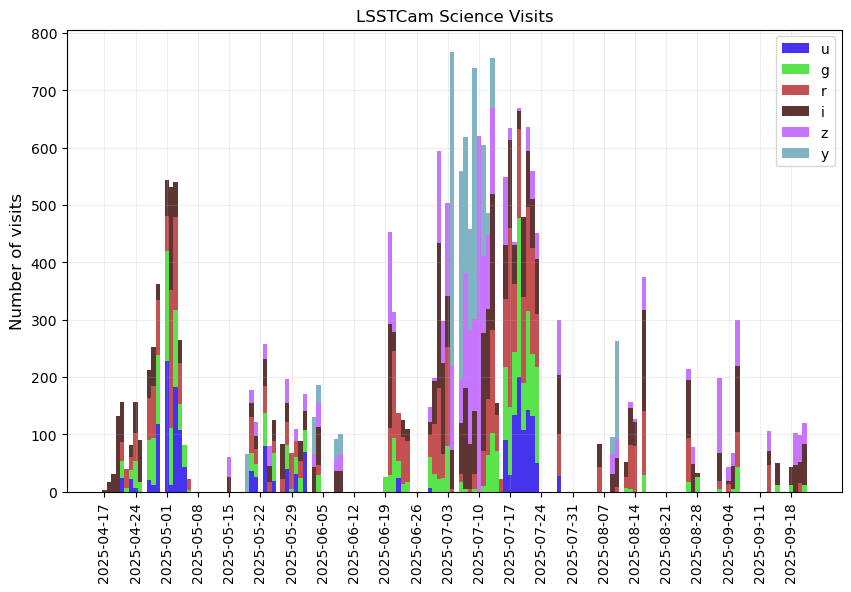

In [20]:
t = Time("2025-04-17T12:00:00", scale='tai')
mjd_to_jd = t.mjd - t.jd
svisits.loc[:, 'jd'] = np.floor(svisits.obs_start_mjd - mjd_to_jd)
svisits.loc[:, 'jd'] = svisits.jd.astype(int)
jds = np.arange(svisits.jd.min(), svisits.jd.max()+1, 1)
jdsbins =  np.arange(svisits.jd.min(), svisits.jd.max()+2, 1)
days = [t.split('T')[0] for t in Time(jds, format='jd', scale='tai').isot]
bar_bottom = np.zeros(len(jds))
plt.figure(figsize=(10, 6))
for b in 'ugrizy':
    heights, _ = np.histogram(svisits.query("band == @b ").jd, bins=jdsbins)
    plt.bar(jds, heights, bottom=bar_bottom, width=1, color=band_colors[b], alpha=0.8, label=b)
    bar_bottom += heights
plt.legend()
_ = plt.xticks(jds[::7], labels=days[::7], rotation=90)
plt.grid(alpha=0.2)
plt.ylabel("Number of visits", fontsize='large')
plt.title("LSSTCam Science Visits")
plt.savefig(os.path.join(out_dir, "lsstcam_scivisits_timing.png"), bbox_inches='tight')

In [21]:
svisits.observation_reason.unique()

array(['field_survey_science', 'pairs', 'template_blob_i_33.0',
       'pairs_gr_33.0', 'template_blob_r_33.0', 'template_blob_z_33.0',
       'pairs_ur_33.0', 'template_blob_g_33.0', 'pairs_ri_33.0',
       'ddf_elaiss1', 'triplet_pairs_iz_33.0', 'pairs_iz_33.0',
       'pairs_ri_15.0', 'pairs_zy_33.0', 'template_blob_y_33.0',
       'pairs_yy_33.0', 'too', 'template_area_singles_i', 'singles_i',
       'pairs_zy_15.0', 'singles_z', 'ddf_edfs_a', 'ddf_ecdfs',
       'ddf_edfs_b', 'pairs_iz_15.0', 'pairs_yy_15.0',
       'triplet_pairs_gr_33.0', 'template_blob_u_33.0', 'pairs_ug_33.0',
       'ddf_xmm_lss', 'singles_r'], dtype=object)

In [22]:
print("total visits", len(svisits))
print("visits for small field survey science", len(svisits.query("observation_reason == 'field_survey_science'")))
total_sv = len(svisits.query("observation_reason != 'field_survey_science'"))
print("visits for SV", len(svisits.query("observation_reason != 'field_survey_science'")))
print("visits for wide SV", len(svisits.query("observation_reason != 'field_survey_science' "\
                                              "and observation_reason != 'template_area_singles_i' "\
                                             "and observation_reason != 'too' and not observation_reason.str.contains('ddf')")))
total_ddf = len(svisits.query("observation_reason.str.contains('ddf')"))
print("visits for ddf", total_ddf, total_ddf/total_sv)
total_too = len(svisits.query("observation_reason.str.contains('too')"))
print("visits for too", total_too, total_too/total_sv)
print("visits prior to 20250703", len(svisits.query("day_obs < 20250703")))
print("visits post 20250703", len(svisits.query("day_obs >= 20250703")))
print("visits prior to 20250724", len(svisits.query("day_obs < 20250724")))

total visits 21628
visits for small field survey science 7194
visits for SV 14434
visits for wide SV 13228
visits for ddf 906 0.06276846335042262
visits for too 189 0.013094083414161009
visits prior to 20250703 8025
visits post 20250703 13603
visits prior to 20250724 18731


In [23]:
ss = svisits.query("observation_reason == 'field_survey_science'").groupby(["target_name", "band"]).agg({'seq_num': 'count'})
ss.rename({"seq_num": "count"}, axis=1, inplace=True)
ss = ss.reset_index('band').pivot(columns=["band"]).droplevel(0, axis=1)
ss = ss[['u', 'g', 'r', 'i', 'z', 'y']]
ss['all'] = ss.sum(axis=1)
ss = ss.query("all > 50").sort_values('all')
ss.index = [i.replace("_", "\\_") for i in ss.index]
rst_table = tabulate(pd.DataFrame(ss.round(0)), headers='keys', tablefmt='rst')
rst_table = rst_table.replace("nan", "---")
print(rst_table)

===================  ===  ===  ===  ===  ===  ===  =====
..                     u    g    r    i    z    y    all
===================  ===  ===  ===  ===  ===  ===  =====
Carina                22   16   23   63  ---  ---    124
Rubin\_SV\_280\_-48   30   30   29   30   29  ---    148
ELAIS\_S1             11   30   30   30   35   30    166
Rubin\_SV\_320\_-15  ---   29   17  105   52   70    273
New\_Horizons         36   49   70  108   74   23    360
Rubin\_SV\_216\_-17  ---   64   95  227  ---  ---    386
Rubin\_SV\_212\_-7   ---  139  236  123  ---  ---    498
Prawn                196  164  149   93   30  ---    632
COSMOS               100   82  166  139  111   66    664
Trifid-Lagoon        235  196  122  115  ---  ---    668
M49                  261  280  378  254  ---  ---   1173
Rubin\_SV\_225\_-40  312  568  441  387  240  104   2052
===================  ===  ===  ===  ===  ===  ===  =====


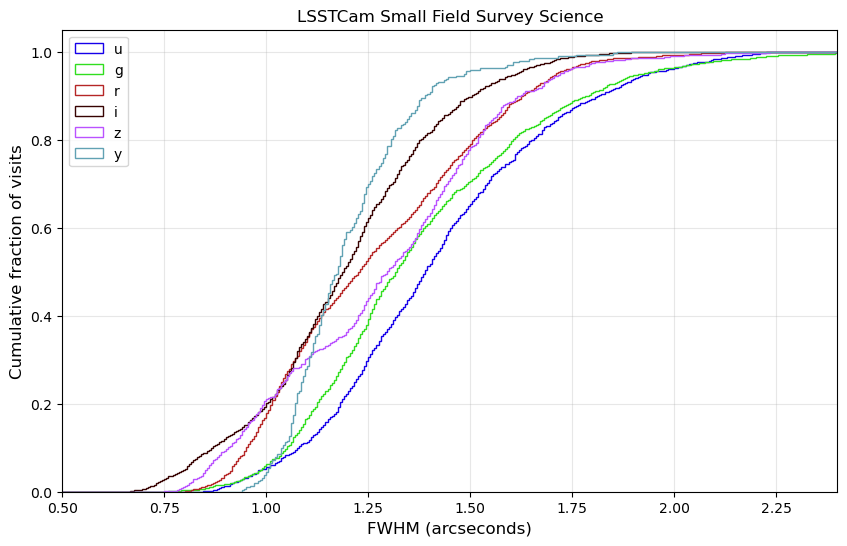

In [24]:
q = svisits.query("observation_reason == 'field_survey_science'")
plt.figure(figsize=(10, 6))
bins = np.arange(0.3, 2.5, 0.005)
for b in 'ugrizy':
    #plt.hist(q.query("band == @b").fwhm_eff, bins=bins, cumulative=1, density=True, alpha=0.3, color=band_colors[b], label=b)
    plt.hist(q.query("band == @b").fwhm_eff, bins=bins, cumulative=1, density=True, histtype='step', color=band_colors[b], label=b)
plt.legend()
plt.xlim(0.5, 2.4)
plt.xlabel("FWHM (arcseconds)", fontsize='large')
plt.ylabel("Cumulative fraction of visits", fontsize='large')
plt.title("LSSTCam Small Field Survey Science")
plt.grid(alpha=0.3)
plt.savefig(os.path.join(out_dir, "smallfield_fwhm.png"))

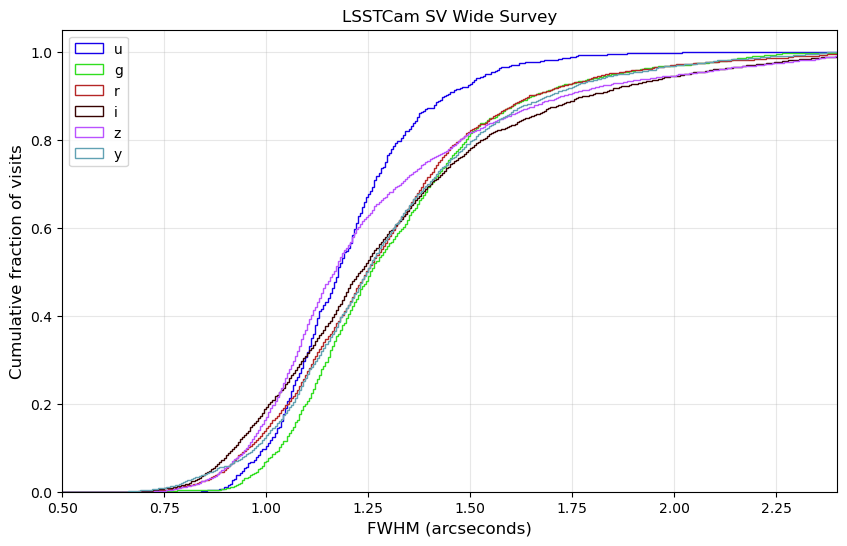

In [25]:
q = svisits.query("observation_reason != 'field_survey_science' and not observation_reason.str.contains('ddf')")
#q = gvisits.query("observation_reason.str.contains('ddf')")
plt.figure(figsize=(10, 6))
bins = np.arange(0.3, 2.5, 0.005)
for b in 'ugrizy':
    #plt.hist(q.query("band == @b").fwhm_eff, bins=bins, cumulative=1, density=True, alpha=0.3, color=band_colors[b], label=b)
    plt.hist(q.query("band == @b").fwhm_eff, bins=bins, cumulative=1, density=True, histtype='step', color=band_colors[b], label=b)
plt.legend()
plt.xlim(0.5, 2.4)
plt.xlabel("FWHM (arcseconds)", fontsize='large')
plt.ylabel("Cumulative fraction of visits", fontsize='large')
plt.title("LSSTCam SV Wide Survey")
plt.grid(alpha=0.3)
plt.savefig(os.path.join(out_dir, "sv_wide_fwhm.png"))

In [26]:
baseline = '/Users/lynnej/opsim/fbs_5.0/baseline_v5.0.1_10yrs.db'
conn = sqlite3.connect(baseline)
baseline_visits = pd.read_sql("select * from observations", conn)

In [28]:
qq = baseline_visits.query("not scheduler_note.str.contains('DD') and not scheduler_note.str.contains('ToO')")
ss = qq.groupby("band").agg({'fiveSigmaDepth': 'median', 'seeingFwhmEff': 'median', 'airmass': 'median', 'cloud': 'median'})
ss = ss.rename({"fiveSigmaDepth": "median m5", "seeingFwhmEff": "median fwhm (arcsec)", 'airmass': "median airmass", 'cloud': "mean cloud (mag)"}, axis=1)
ss = ss.loc[['u', 'g', 'r', 'i', 'z', 'y']]
remap = dict([(b, "baseline " + b) for b in 'ugrizy'])
ss = ss.rename(remap, axis=0)

qq = svisits.query("observation_reason != 'field_survey_science' and not observation_reason.str.contains('ddf')")
ss2 = qq.groupby("band").agg({'cat_m5': 'median', 'fwhm_eff': 'median', 'airmass': 'median', 'clouds': 'mean'})
ss2 = ss2.rename({"cat_m5": "median m5", "fwhm_eff": "median fwhm (arcsec)", "airmass": "median airmass", "clouds": "mean cloud (mag)"}, axis=1)
ss2 = ss2.loc[['u', 'g', 'r', 'i', 'z', 'y']]
remap = dict([(b, "SV " + b) for b in 'ugrizy'])
ss2 = ss2.rename(remap, axis=0)

In [16]:
s = pd.concat([ss, ss2]).loc[["baseline u", "SV u", "baseline g", "SV g", 
                          "baseline r", "SV r", "baseline i", "SV i", 
                          "baseline z", "SV z", "baseline y", "SV y"], 
    ["median airmass", "median fwhm (arcsec)", "mean cloud (mag)", "median m5"]]
rst_table = tabulate(s.round(2), headers='keys', tablefmt='rst')
print(rst_table)

==========  ================  ======================  ==================  ===========
band          median airmass    median fwhm (arcsec)    mean cloud (mag)    median m5
==========  ================  ======================  ==================  ===========
baseline u              1.21                    1.25                0           23.34
SV u                    1.14                    1.18                0.18        23.99
baseline g              1.23                    1.15                0           24.44
SV g                    1.22                    1.26                0.26        24.37
baseline r              1.22                    1.08                0           24.03
SV r                    1.24                    1.26                0.33        23.76
baseline i              1.22                    1.03                0           23.5
SV i                    1.24                    1.24                0.23        23.25
baseline z              1.22                    1.02   

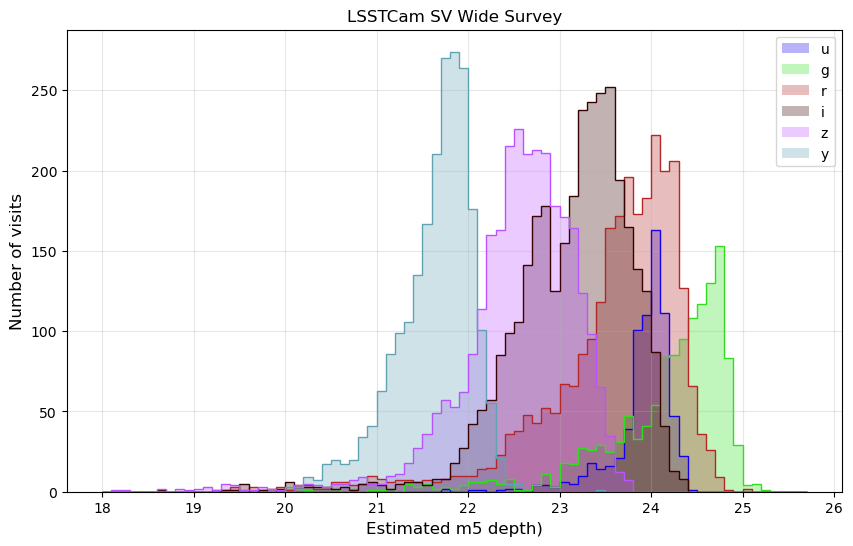

In [29]:
q = svisits.query("observation_reason != 'field_survey_science' and not observation_reason.str.contains('ddf')")
#q = gvisits.query("observation_reason.str.contains('ddf')")
plt.figure(figsize=(10, 6))
bins = np.arange(18, 25.8, 0.1)
for b in 'ugrizy':
    plt.hist(q.query("band == @b").cat_m5, bins=bins, cumulative=0, density=False, alpha=0.3, color=band_colors[b], label=b)
    plt.hist(q.query("band == @b").cat_m5, bins=bins, cumulative=0, density=False, histtype='step', color=band_colors[b])#, label=b)
plt.legend()
plt.xlabel("Estimated m5 depth)", fontsize='large')
plt.ylabel("Number of visits", fontsize='large')
plt.title("LSSTCam SV Wide Survey")
plt.grid(alpha=0.3)
plt.savefig(os.path.join(out_dir, "sv_wide_m5.png"), bbox_inches='tight')

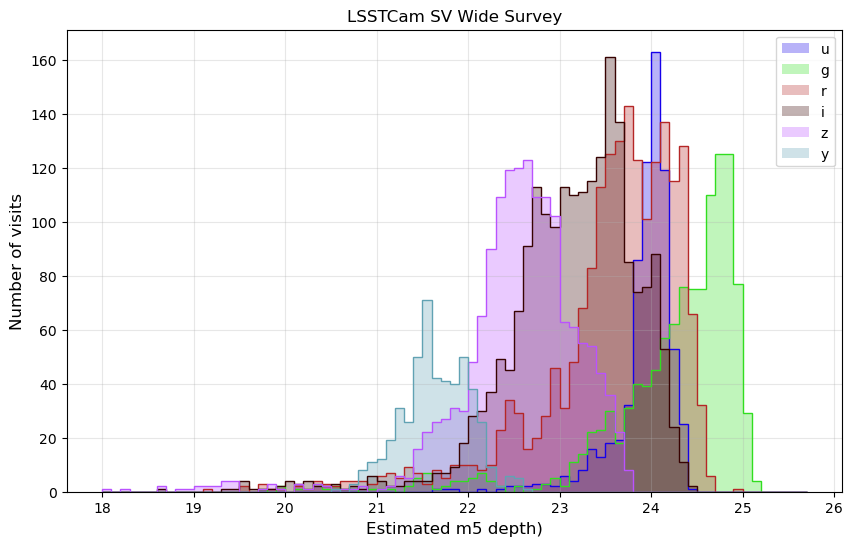

In [30]:
q = svisits.query("observation_reason != 'field_survey_science' and not observation_reason.str.contains('ddf')")
#q = gvisits.query("observation_reason.str.contains('ddf')")
plt.figure(figsize=(10, 6))
bins = np.arange(18, 25.8, 0.1)
for b in 'ugrizy':
    plt.hist(q.query("band == @b").stats_mag_lim_median, bins=bins, cumulative=0, density=False, alpha=0.3, color=band_colors[b], label=b)
    plt.hist(q.query("band == @b").stats_mag_lim_median, bins=bins, cumulative=0, density=False, histtype='step', color=band_colors[b])#, label=b)
plt.legend()
plt.xlabel("Estimated m5 depth)", fontsize='large')
plt.ylabel("Number of visits", fontsize='large')
plt.title("LSSTCam SV Wide Survey")
plt.grid(alpha=0.3)
## DON'T USE THIS ONE -- the stats mag lim was not available for much of SV, and has not been backfilled. Use cat_m5 as it's pretty close anyway.
#plt.savefig(os.path.join(out_dir, "sv_wide_m5.png"))

In [31]:
vv = svisits.query("observation_reason == 'field_survey_science'").groupby(['target_name']).agg({'seq_num': 'count',
                                                                                                 'fwhm_eff': 'median',
                                                                                                 'clouds': 'mean',
                                                                                                 'obs_start_mjd': np.ptp})
vv.rename({"seq_num": "nvisits", 
           "obs_start_mjd": "timespan (days)", 
           "fwhm_eff": "median fwhm (arcsec)", 
           "clouds": "mean cloud (mag)"}, axis=1, inplace=True)
vv = vv.query("nvisits > 50").sort_values("nvisits")
vv['timespan (days)'] = vv['timespan (days)'].astype(int) + 1
vv.round(2)
vv.index = [i.replace("_", "\\_") for i in vv.index]
rst_table = tabulate(pd.DataFrame(vv.round(2)), headers='keys', tablefmt='rst')
rst_table = rst_table.replace("nan", "---")
print(rst_table)

===================  =========  ======================  ==================  =================
..                     nvisits    median fwhm (arcsec)    mean cloud (mag)    timespan (days)
===================  =========  ======================  ==================  =================
Carina                     124                  ---                 ---                     4
Rubin\_SV\_280\_-48        148                    1.52                0.08                  1
ELAIS\_S1                  166                    1.38                0.44                 17
Rubin\_SV\_320\_-15        273                    1.22                0.03                  6
New\_Horizons              360                    1.05                0.2                  62
Rubin\_SV\_216\_-17        386                    1.29                0.01                  8
Rubin\_SV\_212\_-7         498                    1.21                0.05                  7
Prawn                      632                    1.37      

In [32]:
# vv = gvisits.query("observation_reason == 'field_survey_science'").groupby(['target_name', 'band']).agg({'seq_num': 'count', 
#                                                                                                         'fwhm_eff': 'median', 
#                                                                                                         'clouds': 'mean', 
#                                                                                                        'obs_start_mjd': np.ptp})
# vv = vv.reset_index('band')
# vv.rename({"seq_num": "nvisits", 
#            "obs_start_mjd": "timespan (jd)", 
#            "fwhm_eff": "median fwhm (arcsec)", 
#            "clouds": "mean cloud (mag)"}, axis=1, inplace=True)
# nvisits_all = gvisits.query("observation_reason == 'field_survey_science'").groupby("target_name").agg({'obs_start': 'count', 
#                                                                                                        'fwhm_eff': 'median', 
#                                                                                                        'clouds': 'mean',
#                                                                                                       'obs_start_mjd': np.ptp})
# nvisits_all = nvisits_all.rename({'obs_start': 'nvisits', 
#                                   "obs_start_mjd": "timespan (jd)", 
#                                   "fwhm_eff": "median fwhm (arcsec)", 
#                                   "clouds": "mean cloud (mag)"}, axis=1)
# nvisits_all['band'] = 'all'
# vv = pd.concat([nvisits_all, vv])
# vv = vv.pivot(columns=['band'])
# vv['nvisits'] = vv['nvisits'].fillna(0)
# vv['nvisits'] = vv['nvisits'].astype(int)
# #columns = ['_'.join(tt) for tt in vv.columns.to_flat_index()]
# #vv.columns = columns
# vv.sort_values(('nvisits', 'all'), inplace=True)
# vv = vv[vv[('nvisits', 'all')] > 50]
# display(HTML(vv.T.round(2).to_html()))

In [21]:
## make dither pattern plot for COSMOS

ddf_nvisits = {}
ddf_coadd = {}

m_nvis = maf.CountMetric(col='observationStartMJD', metric_name = "Nvisits")
m_coadd = maf.Coaddm5Metric(m5_col='fiveSigmaDepth')

ddfs = ddf_locations(skycoords=True)
s, plot_dict = maf.make_circle_subset_slicer(ddfs['COSMOS'].ra.deg, ddfs['COSMOS'].dec.deg, radius=2.8, nside=512*2, use_cache=False)

for b in ['u', 'g', 'r', 'i', 'z', 'y', 'all']:
    constraint = f"ddf cosmos {b}"
    if b == 'all':
        opsvis = ops_visits.to_records()
    else:
        opsvis = ops_visits.query("band == @b").to_records()
    ddf_nvisits[b] = maf.MetricBundle(m_nvis, s, constraint)
    ddf_coadd[b] = maf.MetricBundle(m_coadd, s, constraint)

    g = maf.MetricBundleGroup({f'nvisits {b}': ddf_nvisits[b], f'coadd {b}': ddf_coadd[b]}, None)
    g.run_current(constraint, opsvis)

Healpix slicer using NSIDE=1024, approximate resolution 3.435486 arcminutes


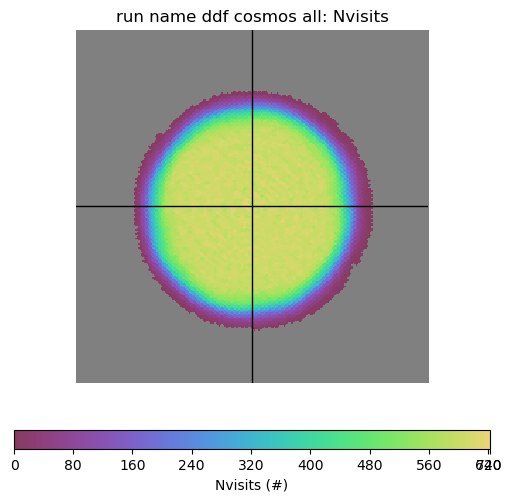

In [22]:
plot_dict['xsize']=250
ph = maf.PlotHandler(thumbnail=False, fig_format='png')
ph.set_metric_bundles([ddf_nvisits['all']])
fig = ph.plot(maf.HealpixSkyMap(), plot_dict)

In [33]:
from rubin_scheduler.scheduler.utils import get_current_footprint
nside = 64
fp, labels = get_current_footprint(nside=nside)
tsurvey_info = svs.survey_times(verbose=True, no_downtime=True)
tsurvey_info.update(svc.survey_footprint(survey_start_mjd=tsurvey_info["survey_start"].mjd, nside=nside))
pp = tsurvey_info["skymap"]["map"]
alpha = np.where(pp >= 0, 1, fp['r'])
alpha = np.where(alpha > 1, 1, alpha)
bg_fp = np.where(fp['r'] == 0, np.nan, fp['r'])
bg_fp = np.where(bg_fp > 1, 1, bg_fp)
sv_fp = np.where(tsurvey_info['fp_array']['r'] > 0, 1, np.nan)

def make_sv_plot(metric_bundle, proj='laea', vmin=None, vmax=None, ax=None, add_bg=True, title=None, label_dec=True):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 7))
    else:
        fig = ax.get_figure()
    
    if proj == 'laea':
        sp = skyproj.LaeaSkyproj( 
            ax=ax,
            celestial=True,
            galactic=False,
            gridlines=True,
            n_grid_lon=8,
            n_grid_lat=5,
            lat_0=-90,
            lon_0=0,
            extent=[0.0, 360.0, -90, 85],
        )
        # Laea only shows half the sky if zoom = True
        # due to bug in current skyproj
        zoom = False
    else: 
        sp = skyproj.McBrydeSkyproj( 
            ax=ax,
            celestial=True,
            galactic=False,
            gridlines=True,
            n_grid_lon=8,
            n_grid_lat=7,
            lon_0=0,
        )
        zoom = True

    if fig is not None and proj == 'laea':
        sp.ax.set_xlabel("R.A.", fontsize=12, labelpad=9)
        if label_dec:
            sp.ax.set_ylabel("Dec.", fontsize=12, labelpad=12)

    if add_bg:
        mesh, lon_raster, lat_raster, values_raster = sp.draw_hpxmap(
            bg_fp, cmap='Greys', vmin=-1, vmax=4, nest=False, zoom=False, zorder=0
        )
        
        mesh, lon_raster, lat_raster, values_raster = sp.draw_hpxmap(
            sv_fp, cmap='Blues', vmin=0, vmax=3, nest=False, zoom=False, zorder=1
        )
        zoom = False
    
    mesh, lon_raster, lat_raster, values_raster = sp.draw_hpxmap(
        metric_bundle.metric_values.filled(np.nan), vmin=vmin, vmax=vmax, nest=False, zoom=zoom, zorder=1.5
    )

    if vmin is None and vmax is None:
        extend = None
    elif vmin is None and vmax is not None:
        extend = "max"
    elif vmin is not None and vmax is None:
        extend = "min"
    else:
        extend = "both"
    _ = sp.draw_colorbar(label=f"{metric_bundle.metric.name} {metric_bundle.info_label}", pad=0.12, shrink=0.5, extend=extend, location="bottom", orientation='horizontal')

    if proj == 'laea':
        pass
    else:
        sp.ax.set_xlabel("R.A.", fontsize=12, labelpad=5)
        if label_dec:
            sp.ax.set_ylabel("Dec.", fontsize=12, labelpad=10)
        else:
            sp.ax.set_ylabel(None)
            
    if title is not None:
        plt.title(title, fontsize='x-large', pad=30)
    return fig

Survey start 2025-06-20 12:00:00.000
Survey end 2025-09-22T12:00:00.000
for a survey length of (nights) 94
Max length of night 11.929420676082373 min length of night 10.158821605145931
Total nighttime 1060.2926793694496, total downtime 144.29456688067876, available time 915.9981124887709
Average availability 0.8634506352129208


In [34]:
# All lsstcam
run_calc = True
if run_calc:
    nvisits = {}
    coadd = {}
    m_nvis = maf.CountMetric(col='obs_start_mjd', metric_name = "Nvisits")
    m_coadd = maf.Coaddm5Metric(m5_col='cat_m5')
    s = maf.HealpixSlicer(nside=64, lat_col='s_dec', lon_col='s_ra', rot_sky_pos_col_name = 'sky_rotation')
    for b in ['u', 'g', 'r', 'i', 'z', 'y', 'all']:
        constraint = f"{b}"
        if b == 'all':
            opsvis = svisits.to_records()
        else:
            opsvis = svisits.query("band == @b").to_records()
        nvisits[b] = maf.MetricBundle(m_nvis, s, constraint)
        coadd[b] = maf.MetricBundle(m_coadd, s, constraint)
        g = maf.MetricBundleGroup({f'nvisits {b}': nvisits[b], f'coadd {b}': coadd[b]}, None)
        g.run_current(constraint, opsvis)

Healpix slicer using NSIDE=64, approximate resolution 54.967783 arcminutes


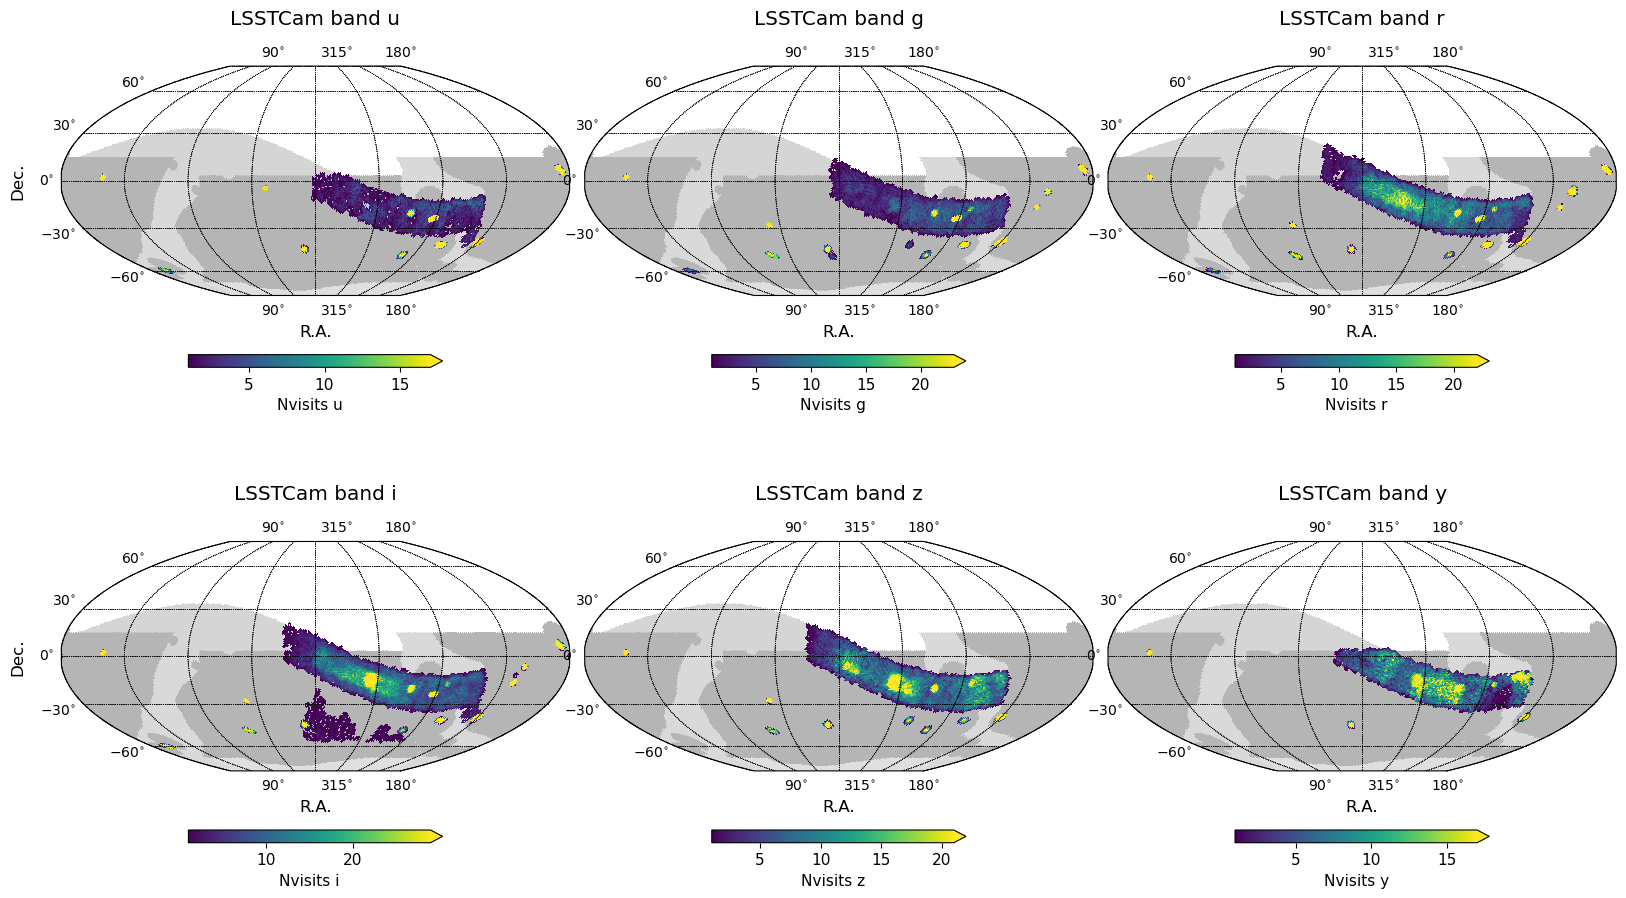

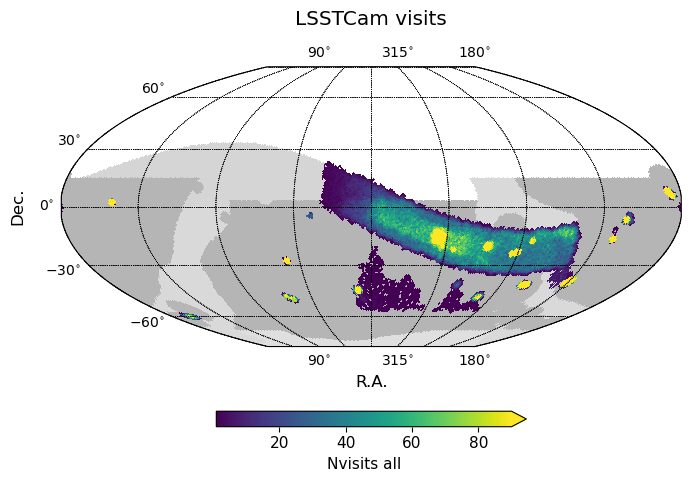

In [35]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(16, 10),)
axdict = {"u": ax[0][0], "g": ax[0][1], "r": ax[0][2],
          "i": ax[1][0], "z": ax[1][1], "y": ax[1][2], "all": None}
for b in ["u", "g", "r", "i", "z", "y"]:
    if len(nvisits[b].metric_values.compressed()) > 1:
        vmax = np.percentile(nvisits[b].metric_values.compressed(), 95)
    else:
        vmax = None
    label_dec = False
    if b == 'u' or b == 'i':
        label_dec = True
    fig = make_sv_plot(nvisits[b], proj='McBryde', vmax=vmax, ax=axdict[b], title=f"LSSTCam band {b}", label_dec=label_dec)
fig.tight_layout()
fig.savefig(os.path.join(out_dir, f"lsstcam_nvisits_band.png"), bbox_inches='tight')

vmax = np.percentile(nvisits['all'].metric_values.compressed(), 95)
fig = make_sv_plot(nvisits['all'], proj='mcbryde', vmin=None, vmax=vmax, ax=None, add_bg=True, title=f"LSSTCam visits")
fig.savefig(os.path.join(out_dir, f"lsstcam_nvisits.png"), bbox_inches='tight')

In [36]:
# sv only
run_calc = True
if run_calc:
    sv_nvisits = {}
    sv_coadd = {}
    m_nvis = maf.CountMetric(col='obs_start_mjd', metric_name = "Nvisits")
    m_coadd = maf.Coaddm5Metric(m5_col='cat_m5')
    s = maf.HealpixSlicer(nside=64, lat_col='s_dec', lon_col='s_ra', rot_sky_pos_col_name = 'sky_rotation')
    for b in ['u', 'g', 'r', 'i', 'z', 'y', 'all']:
        constraint = f"{b}"
        if b == 'all':
            opsvis = svisits.query("observation_reason!='field_survey_science'").to_records()
        else:
            opsvis = svisits.query("observation_reason!='field_survey_science' and band == @b").to_records()
        sv_nvisits[b] = maf.MetricBundle(m_nvis, s, constraint)
        sv_coadd[b] = maf.MetricBundle(m_coadd, s, constraint)
        g = maf.MetricBundleGroup({f'nvisits {b}': sv_nvisits[b], f'coadd {b}': sv_coadd[b]}, None)
        g.run_current(constraint, opsvis)

Healpix slicer using NSIDE=64, approximate resolution 54.967783 arcminutes


In [37]:
allsky = generate_all_sky(nside=64)

mask_v1 = np.where(
        (
            (np.abs(allsky["eclip_lat"]) < 10)
            & ((allsky["eclip_lon"] > 240) | (allsky["eclip_lon"] < 40))
        ),
        1,
        np.nan,
    )

mask_v2 = np.where(
        ((np.abs(allsky["eclip_lat"]) < 5) & (allsky["eclip_lon"] > 285)),
        1,
        np.nan,
    )

mask_v3 = np.where(
    (allsky["ra"] > 300)
    & (allsky["ra"] < 324)
    & (allsky["dec"] > -26)
    & (allsky["dec"] < -10) 
    & (allsky['eclip_lat'] < 5),
    1,
    np.nan,
)

In [39]:
print("v1 area", len(np.where(~np.isnan(mask_v1))[0]) * hp.nside2pixarea(64, degrees=True))
print("v2 area", len(np.where(~np.isnan(mask_v2))[0]) * hp.nside2pixarea(64, degrees=True))
print("v3 area", len(np.where(~np.isnan(mask_v3))[0]) * hp.nside2pixarea(64, degrees=True))

v1 area 3188.476558157223
v2 area 756.2035743352612
v3 area 308.0207677924982


In [40]:
summary = {}
summary['3k'] = pd.DataFrame([[np.nanmedian(sv_nvisits[b].metric_values.filled(0) * mask_v1) for b in sv_nvisits],
                              [np.nanmedian(sv_coadd[b].metric_values.filled(0) * mask_v1) for b in sv_coadd]],
                      columns=list(sv_nvisits.keys()), index=[f'Nvisits', f'CoaddM5'])
summary['750'] = pd.DataFrame([[np.nanmedian(sv_nvisits[b].metric_values.filled(0) * mask_v2) for b in sv_nvisits],
                              [np.nanmedian(sv_coadd[b].metric_values.filled(0) * mask_v2) for b in sv_coadd]],
                      columns=list(sv_nvisits.keys()), index=[f'Nvisits', f'CoaddM5'])
summary['300'] = pd.DataFrame([[np.nanmedian(sv_nvisits[b].metric_values.filled(0) * mask_v3) for b in sv_nvisits],
                              [np.nanmedian(sv_coadd[b].metric_values.filled(0) * mask_v3) for b in sv_coadd]],
                      columns=list(sv_nvisits.keys()), index=[f'Nvisits', f'CoaddM5'])
summary = pd.concat(summary)
display(summary.round(2))
rst_table = tabulate(pd.DataFrame(summary.round(1)), headers='keys', tablefmt='rst')
print(rst_table)

u      g      r      i      z      y    all
3k  Nvisits   2.00   4.00   7.00   8.00   7.00   5.00  38.00
    CoaddM5  24.18  25.04  24.91  24.51  23.84  22.63  25.53
750 Nvisits   2.00   4.00  12.00  15.00  11.00   9.00  56.00
    CoaddM5  24.38  25.21  25.18  24.82  23.96  22.99  25.77
300 Nvisits   2.00   5.00  11.00  18.00  15.00  10.00  64.00
    CoaddM5  24.47  25.15  25.02  24.85  24.11  23.05  25.72

==================  ====  ====  ====  ====  ====  ====  =====
..                     u     g     r     i     z     y    all
==================  ====  ====  ====  ====  ====  ====  =====
('3k', 'Nvisits')    2     4     7     8     7     5     38
('3k', 'CoaddM5')   24.2  25    24.9  24.5  23.8  22.6   25.5
('750', 'Nvisits')   2     4    12    15    11     9     56
('750', 'CoaddM5')  24.4  25.2  25.2  24.8  24    23     25.8
('300', 'Nvisits')   2     5    11    18    15    10     64
('300', 'CoaddM5')  24.5  25.2  25    24.9  24.1  23     25.7
==================  ====  ====  ====  ====  ====  ====  =====


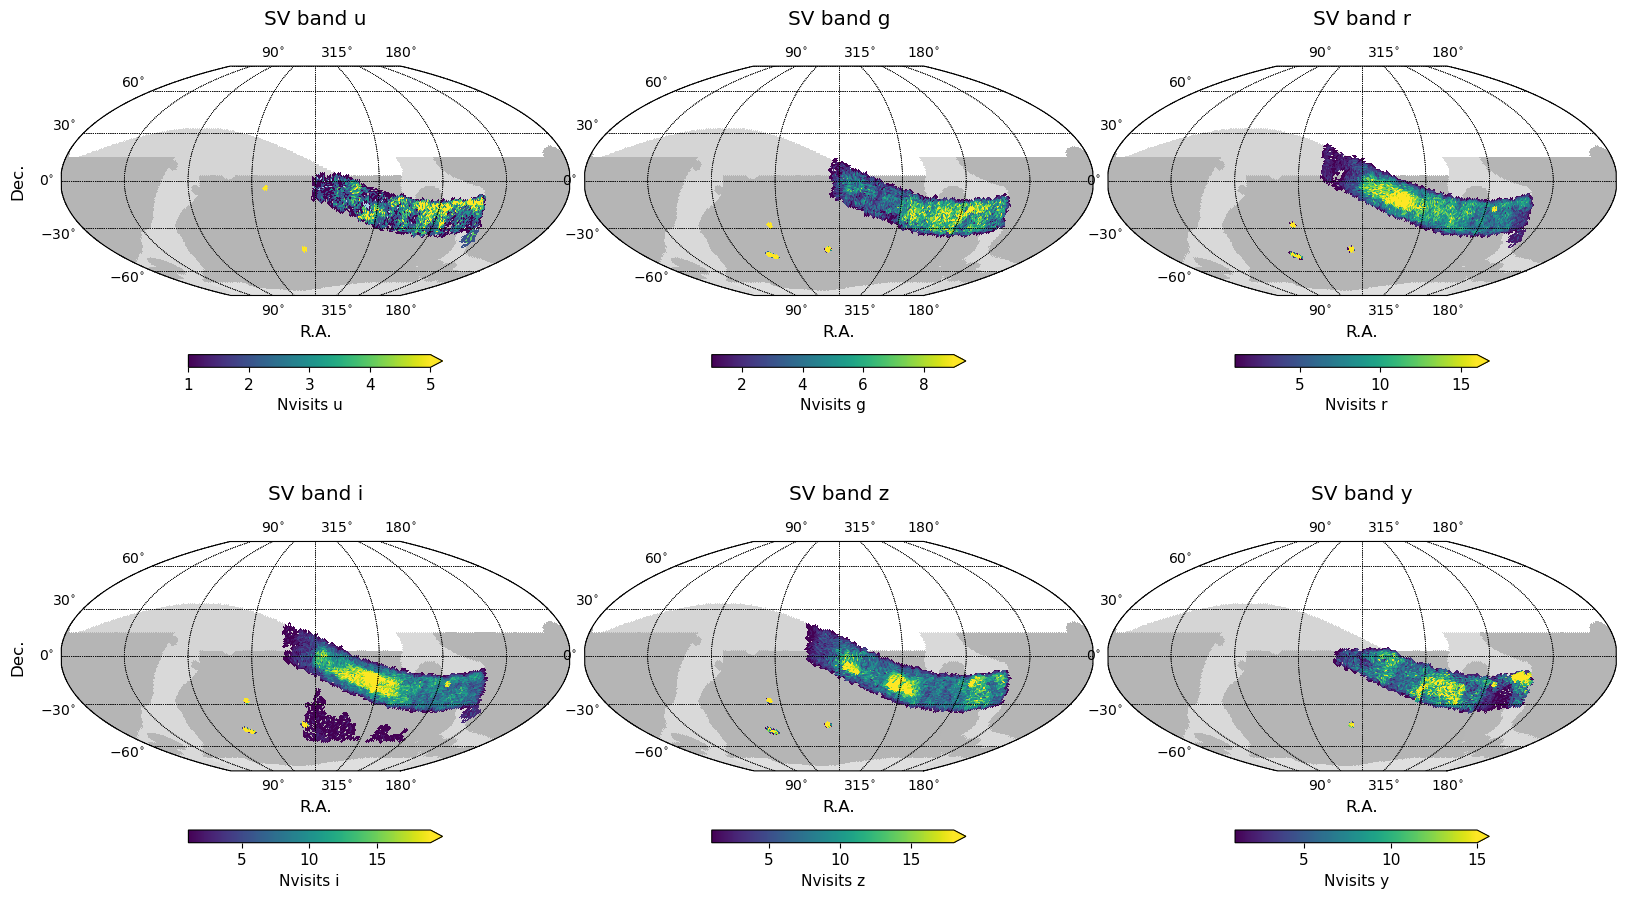

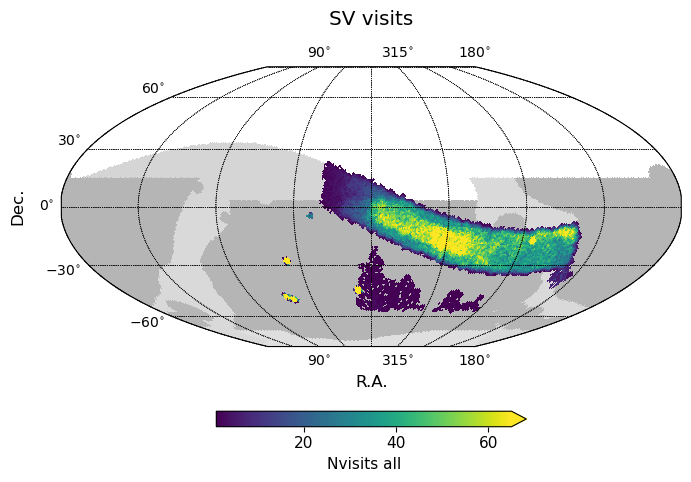

In [41]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(16, 10),)
axdict = {"u": ax[0][0], "g": ax[0][1], "r": ax[0][2],
          "i": ax[1][0], "z": ax[1][1], "y": ax[1][2], "all": None}
for b in ["u", "g", "r", "i", "z", "y"]:
    if len(sv_nvisits[b].metric_values.compressed()) > 1:
        vmax = np.percentile(sv_nvisits[b].metric_values.compressed(), 95)
    else:
        vmax = None
    label_dec = False
    if b == 'u' or b == 'i':
        label_dec = True
    fig = make_sv_plot(sv_nvisits[b], proj='McBryde', vmax=vmax, ax=axdict[b], title=f"SV band {b}", label_dec=label_dec)
fig.tight_layout()
fig.savefig(os.path.join(out_dir, f"sv_nvisits_band.png"), bbox_inches='tight')

vmax = np.percentile(sv_nvisits['all'].metric_values.compressed(), 95)
fig = make_sv_plot(sv_nvisits['all'], proj='mcbryde', vmin=None, vmax=vmax, ax=None, add_bg=True, title=f"SV visits")
fig.savefig(os.path.join(out_dir, f"sv_nvisits.png"), bbox_inches='tight')

In [48]:
ss = svisits.query("observation_reason.str.contains('ddf')").groupby(["observation_reason", "band"]).agg({'seq_num': 'count'})
ss.rename({"seq_num": "count"}, axis=1, inplace=True)
ss = ss.reset_index('band').pivot(columns=["band"]).droplevel(0, axis=1)
ss = ss[['u', 'g', 'r', 'i', 'z', 'y']]
ss['all'] = ss.sum(axis=1)
ss = ss.sort_values('all')
ss.index = [i.replace("_", "\\_") for i in ss.index]
rst_table = tabulate(pd.DataFrame(ss.round(0)), headers='keys', tablefmt='rst')
rst_table = rst_table.replace("nan", "---")
print(rst_table)

=============  ===  ===  ===  ===  ===  ===  =====
..               u    g    r    i    z    y    all
=============  ===  ===  ===  ===  ===  ===  =====
ddf\_xmm\_lss   30  ---  ---  ---  ---  ---     30
ddf\_edfs\_a   ---   20   21   28   18  ---     87
ddf\_edfs\_b   ---   23   21   29   18  ---     91
ddf\_ecdfs     ---   36   39   41   43  ---    159
ddf\_elaiss1    39  101  103  168  112   16    539
=============  ===  ===  ===  ===  ===  ===  =====


In [49]:
vv = svisits.query("observation_reason.str.contains('ddf')").groupby(['observation_reason']).agg({'seq_num': 'count',
                                                                                                 'fwhm_eff': 'median',
                                                                                                 'clouds': 'mean',
                                                                                                 'obs_start_mjd': np.ptp})
vv.rename({"seq_num": "nvisits", 
           "obs_start_mjd": "timespan (days)", 
           "fwhm_eff": "median fwhm (arcsec)", 
           "clouds": "mean cloud (mag)"}, axis=1, inplace=True)
vv['timespan (days)'] = vv['timespan (days)'].astype(int) + 1
vv = vv.sort_values('nvisits')
vv.round(2)
vv.index = [i.replace("_", "\\_") for i in vv.index]
rst_table = tabulate(pd.DataFrame(vv.round(2)), headers='keys', tablefmt='rst')
rst_table = rst_table.replace("nan", "---")
print(rst_table)

=============  =========  ======================  ==================  =================
..               nvisits    median fwhm (arcsec)    mean cloud (mag)    timespan (days)
=============  =========  ======================  ==================  =================
ddf\_xmm\_lss         30                    1.47                0.07                 10
ddf\_edfs\_a          87                    1.32                0.16                 55
ddf\_edfs\_b          91                    1.36                0.13                 55
ddf\_ecdfs           159                    1.51                0.17                 57
ddf\_elaiss1         539                    1.4                 0.1                  84
=============  =========  ======================  ==================  =================


In [50]:
scale = hp.nside2pixarea(nside, degrees=True) #/ 1000.0
for b in 'ugrizy':
    print(b, len(sv_nvisits[b].metric_values.compressed()) * scale)

u 2717.632823193758
g 3022.2964164054115
r 3666.0346422823764
i 4389.505764454402
z 3518.318960725211
y 2990.403257887387


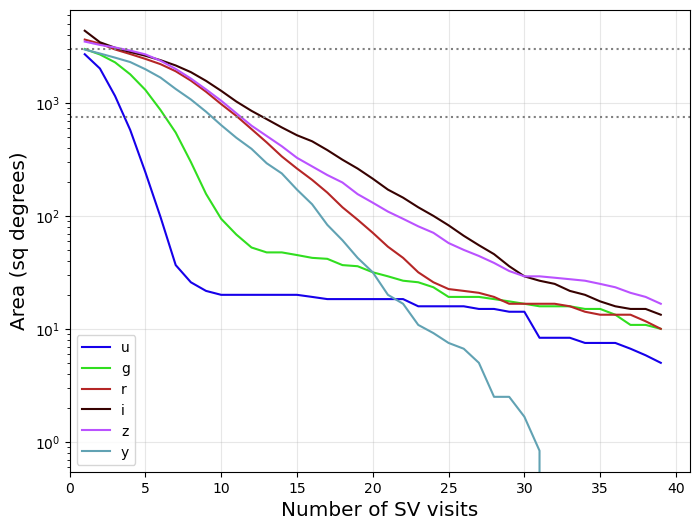

In [51]:
y1nvis = {'u': 6, 'g':8, 'r':  18, 'i': 18, 'z': 16, 'y': 16} 
threshold = np.arange(1, 40, 1)
fig, ax = plt.subplots(figsize=(8, 6))
for b in 'ugrizy':
    area = np.zeros(len(threshold))
    for i, t in enumerate(threshold):
        joint = np.where(sv_nvisits[b].metric_values.filled(0) >= t, 1, 0)
        area[i] = len(np.where(joint >= 1)[0]) *  scale
    ax.plot(threshold, area, label=b, color=band_colors[b])
ax.axhline(3000, color='gray', linestyle=':')
ax.axhline(750, color='gray', linestyle=':')
ax.legend()
ax.set_xlabel("Number of SV visits", fontsize='x-large')
ax.set_ylabel("Area (sq degrees)", fontsize='x-large')
ax.set_yscale('log')
#ax.set_ylim(0, None)
ax.set_xlim(0,None)
ax.grid(alpha=0.3)
plt.savefig(os.path.join(out_dir, "sv_area_per_band.png"))

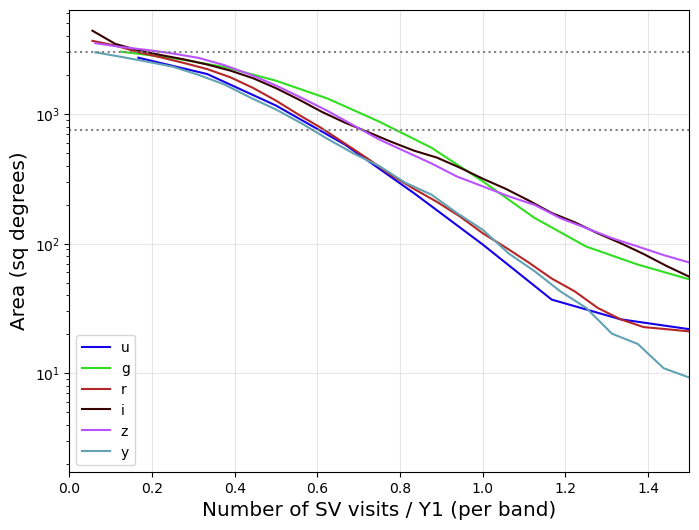

In [52]:
y1nvis = {'u': 6, 'g':8, 'r':  18, 'i': 18, 'z': 16, 'y': 16} 
threshold = np.arange(1, 30, 1)
fig, ax = plt.subplots(figsize=(8, 6))
for b in 'ugrizy':
    area = np.zeros(len(threshold))
    for i, t in enumerate(threshold):
        joint = np.where(sv_nvisits[b].metric_values.filled(0) >= t, 1, 0)
        area[i] = len(np.where(joint >= 1)[0]) *  scale
    ax.plot(threshold/y1nvis[b], area, label=b, color=band_colors[b])
ax.axhline(3000, color='gray', linestyle=':')
ax.axhline(750, color='gray', linestyle=':')
ax.legend()
ax.set_xlabel("Number of SV visits / Y1 (per band)", fontsize='x-large')
ax.set_ylabel("Area (sq degrees)", fontsize='x-large')
ax.set_yscale('log')
#ax.set_ylim(0, None)
ax.set_xlim(0, 1.5)
ax.grid(alpha=0.3)
plt.savefig(os.path.join(out_dir, "sv_area_per_band_scaled.png"), bbox_inches='tight')

In [53]:
# Minimum slewtime in SV visits -- good and bad
sv_visits = gvisits.query("science_program == 'BLOCK-365' and observation_reason!='block-t548' and observation_reason!='field_survey_science'")
len(sv_visits), len(gvisits)

(14434, 50931)

In [54]:
# SV survey initial simulation visits
opsdb = 'sv_sim_1.0.db'
sv_orig_name = opsdb.replace('.db', '')
conn = sqlite3.connect(opsdb)
sv_orig_visits = pd.read_sql("select * from observations", conn)

# SV survey initial simulation visits
opsdb = 'sv_20250620/sv_20250620.db'
conn = sqlite3.connect(opsdb)
sv_osim_visits = pd.read_sql("select * from observations", conn)

In [55]:
print(len(sv_orig_visits), len(sv_osim_visits))

48805 38114


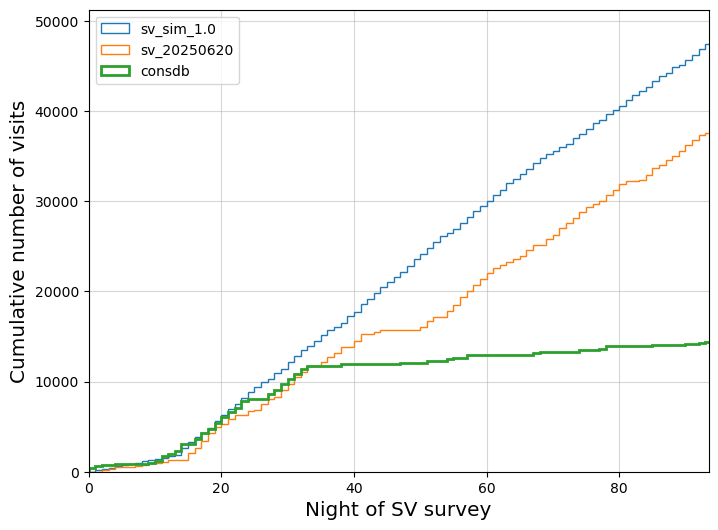

In [56]:
plt.figure(figsize=(8, 6))

gq = sv_visits.copy()
gq.loc[:, 'night'] = np.floor(gq.obs_start_mjd - 0.5) - Time("2025-06-20T12:00:00", scale='tai').mjd + 1

night_cut = gq.night.max() 
night_cut = 100
nights = np.arange(0, night_cut+1) 

_ = plt.hist(sv_orig_visits.night, bins=nights, histtype='step', cumulative=True, label='sv_sim_1.0')
_ = plt.hist(sv_osim_visits.night, bins=nights, histtype='step', cumulative=True, label='sv_20250620')
_ = plt.hist(gq.night, bins=nights, histtype='step', cumulative=True, label='consdb', linewidth=2)

plt.legend()

plt.xlim(0, gq.night.max())
plt.grid(alpha=0.5)
plt.xlabel("Night of SV survey", fontsize='x-large')
plt.ylabel("Cumulative number of visits", fontsize='x-large')
plt.savefig(os.path.join(out_dir, "sv_cumulative.png"), bbox_inches='tight')

In [57]:
print('sv no weather', (sv_orig_visits.visitExposureTime + sv_orig_visits.slewTime).sum()/60/60)
print('sv with weather', (sv_osim_visits.visitExposureTime + sv_osim_visits.slewTime).sum()/60/60)
print('actual sv', (sv_visits.shut_time  +  sv_visits.overhead).sum()/60/60)
188/463, len(sv_visits), len(sv_osim_visits), len(sv_orig_visits), len(sv_visits) / len(sv_osim_visits), len(sv_visits) /len(sv_orig_visits)

sv no weather 645.2962221365328
sv with weather 463.8657942522902
actual sv 183.9733341324251


(0.4060475161987041,
 14434,
 38114,
 48805,
 0.37870598730125415,
 0.295748386435816)

In [20]:
#sv_visits.iloc[filter_change][['visit_id', 'day_obs', 'seq_num', 'band', 'slew_model', 'overhead', 'fault', 'visit_gap', 'model_gap']]

In [29]:
sv_visits = gvisits.query("science_program == 'BLOCK-365' and observation_reason != 'block-t548' and observation_reason != 'field_survey_science'")

Text(0.5, 1.0, 'SV survey visits with filter change')

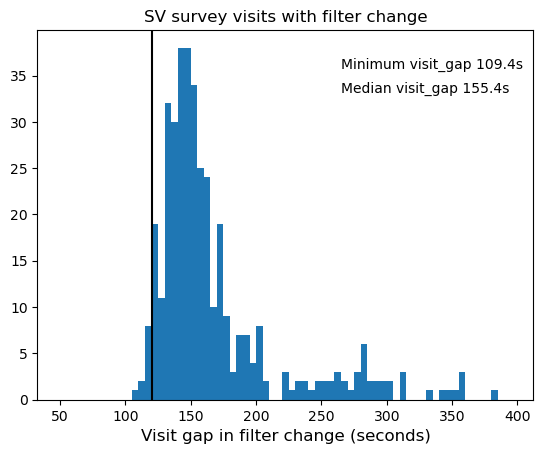

In [34]:
q = sv_visits.query("filter_change == 1")
_ = plt.hist(q.visit_gap, bins=np.arange(50, 400, 5))
plt.xlabel("Visit gap in filter change (seconds)", fontsize='large')
plt.figtext(0.6, 0.8, f"Minimum visit_gap {q.visit_gap.min():.1f}s")
plt.figtext(0.6, 0.75, f"Median visit_gap {q.visit_gap.median():.1f}s")
plt.axvline(120, color='black')
plt.title("SV survey visits with filter change")

In [73]:
q = sv_visits.query("filter_change == 1")
tenpercentile = np.percentile(q.fault.values, 90)/60
print("tenpercentile value (min)", tenpercentile)
print(np.percentile(q.fault.values, 80), '90%ile (min)', np.percentile(q.fault.values, 90)/60, 'max minutes', q.fault.values.max()/60)
print(q.query("fault > 40").fault.sum()/60/60)
print(len(q.query("fault > 240")) / len(q))
print('15 minute', len(q.query("fault > 15*60")) / len(q))
print('1 hour', len(q.query("fault > 60*60")) / len(q))
print(q.query("fault > 20*60").day_obs.unique())

tenpercentile value (min) 4.194429852742802
25.877478737699295 90%ile (min) 4.194429852742802 max minutes 33.20048716678434
7.779396242039986
0.10161662817551963
15 minute 0.011547344110854504
1 hour 0.0
[20250720 20250728]


In [72]:
q.query("fault > 5*60")[['visit_id', 'band', 'visit_gap', 'slew_model', 'model_gap', 'fault']]
visits.query("visit_id > 2025091900243 and visit_id < 2025091900249")[['visit_id', 'obs_start', 'band', 'visit_gap', 'slew_model', 'model_gap', 'fault']]

,visit_id,obs_start,band,visit_gap,slew_model,model_gap,fault
8500,2025091900244,2025-09-20T04:25:58.149000,i,9.691585,8.729303,0.962283,0.000000
23369,2025091900245,2025-09-20T04:26:39.151000,i,10.073882,9.467960,0.605921,0.000000
19407,2025091900246,2025-09-20T04:27:19.999000,i,9.916292,9.162513,0.753779,0.000000
8501,2025091900247,2025-09-20T04:38:01.775000,z,610.840869,130.306602,480.534266,474.534266
47308,2025091900248,2025-09-20T04:38:41.581000,z,8.875282,3.529874,5.345408,0.000000


In [74]:
#display(HTML(endpoints['night_report'].query_night_report(20250728)[-1]))

Text(0.5, 1.0, 'SV survey visits with filter change')

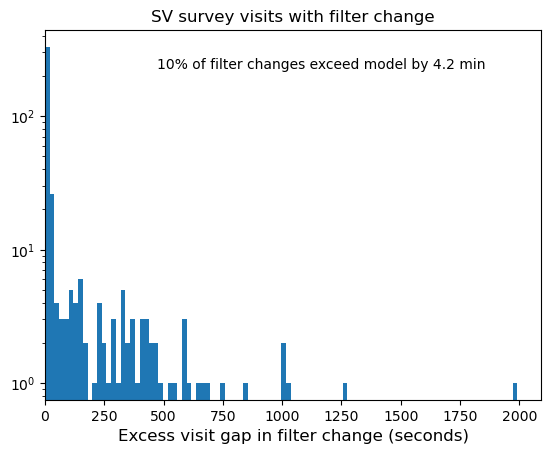

In [78]:
q = sv_visits.query("filter_change == 1")
_ = plt.hist(q.fault, bins=100)#np.arange(0, 2000, 45))
plt.xlabel("Excess visit gap in filter change (seconds)", fontsize='large')
#plt.ylim(0, 10)
plt.yscale('log')
plt.xlim(0, None)
plt.figtext(0.3, 0.8, f"10% of filter changes exceed model by {tenpercentile :.1f} min")
#plt.axvline(45, color='k')
plt.title("SV survey visits with filter change")

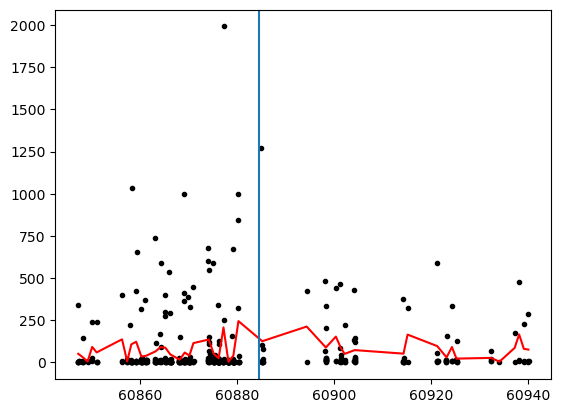

In [50]:
q = sv_visits.query("filter_change == 1")
plt.plot(q.obs_start_mjd, q.fault, 'k.')
qq = q.groupby("day_obs").agg({"obs_start_mjd": "mean", "fault": "mean"})
plt.plot(qq.obs_start_mjd, qq.fault, 'r-')
plt.axvline(Time("2025-07-28T12:00:00").mjd)

Text(0.5, 1.0, 'All SV survey visits')

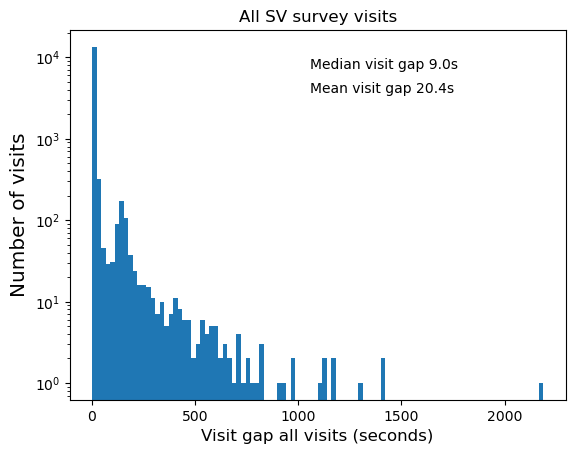

In [89]:
q = sv_visits
_ = plt.hist(q.overhead + q.fault, bins=100)#np.arange(0, 60*60, 40))
plt.yscale('log')
plt.ylabel("Number of visits", fontsize='x-large')
plt.xlabel("Visit gap all visits (seconds)", fontsize='large')
plt.figtext(0.5, 0.80, f"Median visit gap {(q.overhead + q.fault).median():.1f}s")
plt.figtext(0.5, 0.75, f"Mean visit gap {(q.overhead + q.fault).mean():.1f}s")
plt.title("All SV survey visits")

Text(0.5, 1.0, 'All SV survey visits')

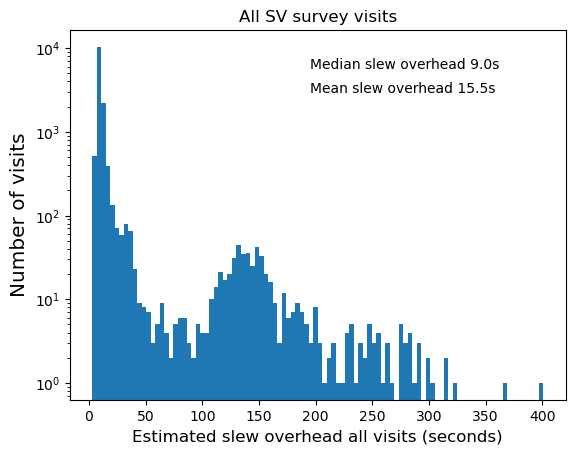

In [90]:
q = sv_visits
_ = plt.hist(q.overhead, bins=100)#np.arange(0, 60, 2))
plt.yscale('log')
plt.ylabel("Number of visits", fontsize='x-large')
plt.xlabel("Estimated slew overhead all visits (seconds)", fontsize='large')
plt.figtext(0.5, 0.8, f"Median slew overhead {q.overhead.median():.1f}s")
plt.figtext(0.5, 0.75, f"Mean slew overhead {q.overhead.mean():.1f}s")
plt.title("All SV survey visits")

In [99]:
q = sv_visits.query("filter_change == 0")
perc = np.nanpercentile(q.fault.values, 99)/60
print("?percentile value (min)", perc)
print(np.nanpercentile(q.fault.values, 80), '90%ile (min)', np.nanpercentile(q.fault.values, 90)/60, 'max minutes', np.nanmax(q.fault.values)/60)
print(q.query("fault > 0").fault.sum()/60/60)
print(len(q.query("fault > 240")) / len(q))
print('15 minute', len(q.query("fault > 15*60")) / len(q))
print('1 hour', len(q.query("fault > 60*60")) / len(q))
print(q.query("fault > 20*60").day_obs.unique())

?percentile value (min) 1.0162557116935025
0.0 90%ile (min) 0.0 max minutes 21.64121005325495
11.18292565214341
0.004136947218259629
15 minute 0.0002853067047075606
1 hour 0.0
[20250719 20250918]


Text(0.5, 1.0, 'All non-filter-change SV survey visits')

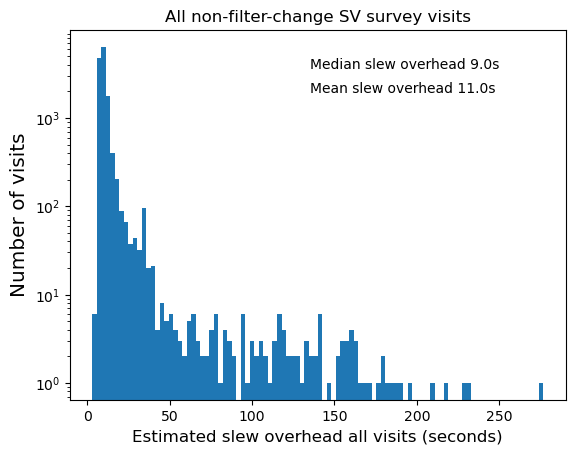

In [86]:
q = sv_visits.query("filter_change == 0")
_ = plt.hist(q.overhead, bins=100)#np.arange(0, 60, 2))
plt.yscale('log')
plt.ylabel("Number of visits", fontsize='x-large')
plt.xlabel("Estimated slew overhead all visits (seconds)", fontsize='large')
plt.figtext(0.5, 0.8, f"Median slew overhead {q.overhead.median():.1f}s")
plt.figtext(0.5, 0.75, f"Mean slew overhead {q.overhead.mean():.1f}s")
plt.title("All non-filter-change SV survey visits")

Text(0.5, 1.0, 'All non-filter-change SV survey visits')

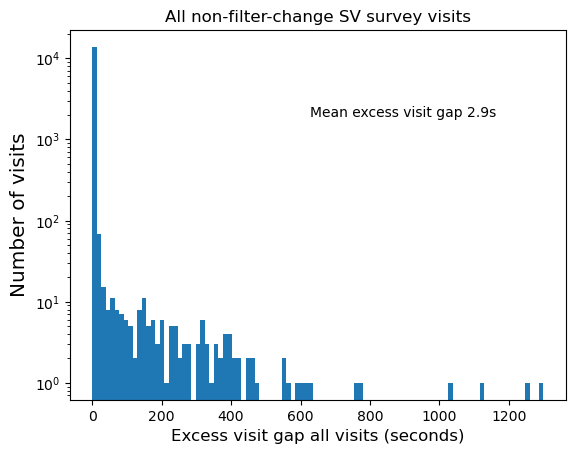

In [85]:
q = sv_visits.query("filter_change == 0")
#plt.plot(q.day_obs, q.visit_gap, 'k.')
_ = plt.hist(q.fault, bins=100)#np.arange(0, 60*60, 40))
plt.yscale('log')
plt.ylabel("Number of visits", fontsize='x-large')
plt.xlabel("Excess visit gap all visits (seconds)", fontsize='large')
#plt.figtext(0.5, 0.80, f"Minimum excess visit gap {q.fault.min():.1f}s")
#plt.figtext(0.5, 0.75, f"Median excess visit gap {q.fault.median():.1f}s")
plt.figtext(0.5, 0.70, f"Mean excess visit gap {q.fault.mean():.1f}s")
plt.title("All non-filter-change SV survey visits")

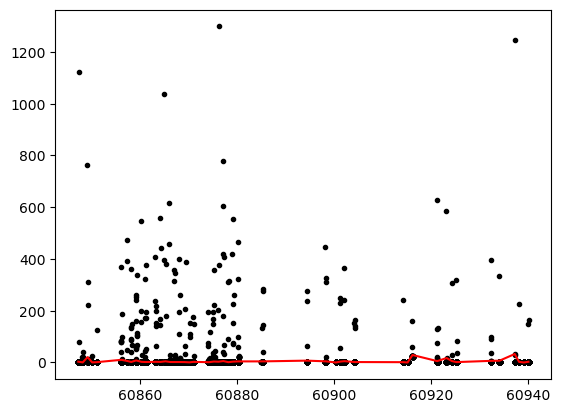

In [101]:
q = sv_visits.query("filter_change == 0")
plt.plot(q.obs_start_mjd, q.fault, 'k.')
qq = q.groupby("day_obs").agg({"obs_start_mjd": "mean", "fault": "mean"})
plt.plot(qq.obs_start_mjd, qq.fault, 'r-')

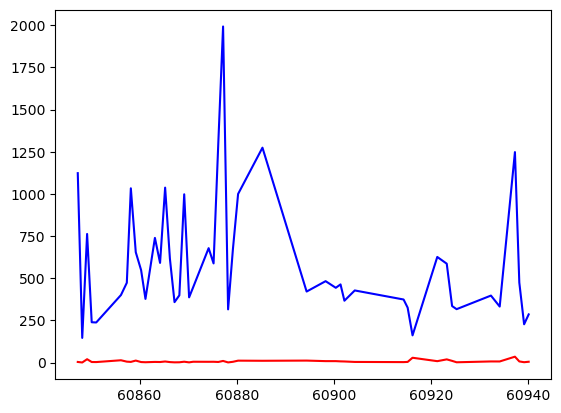

In [107]:
q = sv_visits 
#plt.plot(q.obs_start_mjd, q.fault, 'k.')
qq = q.groupby("day_obs").agg({"obs_start_mjd": "mean", "fault": "mean"})
plt.plot(qq.obs_start_mjd, qq.fault, 'r-')
qq = q.groupby("day_obs").agg({"obs_start_mjd": "mean", "fault": "max"})
plt.plot(qq.obs_start_mjd, qq.fault, 'b-')

Text(0.5, 1.0, 'All SV visits')

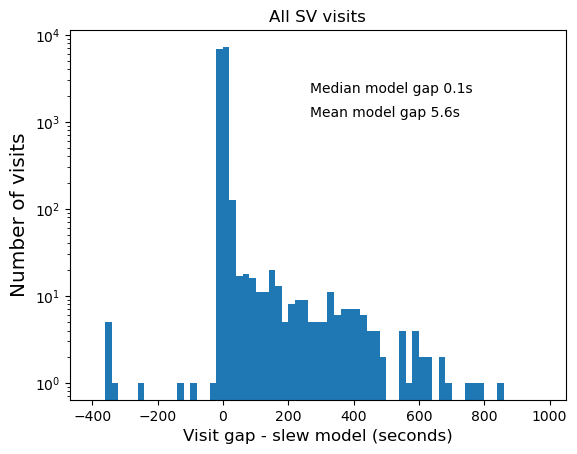

In [108]:
_ = plt.hist(sv_visits.model_gap, bins=np.arange(-400, 1000, 20))
plt.yscale('log')
plt.figtext(0.5, 0.75, f"Median model gap {sv_visits.model_gap.median():.1f}s")
plt.figtext(0.5, 0.70, f"Mean model gap {sv_visits.model_gap.mean():.1f}s")
plt.ylabel("Number of visits", fontsize='x-large')
plt.xlabel("Visit gap - slew model (seconds)", fontsize='large')           
plt.title("All SV visits")

In [192]:
len(sv_visits.query("model_gap > 10"))/len(sv_visits), sv_visits.query("model_gap > 10").fault.sum()/60/60/24

(0.03861581344754912, np.float64(72.72450987903801))